# 06 Visualizing PCs

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import sys
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
import pickle as pkl
import joblib
from collections import defaultdict

from statsmodels.api import OLS

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, r2_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.colors import Normalize

sys.path.append('../..')
from nonlinear_significance.scripts.TreeTester import TreeTester
from nonlinear_significance.scripts.util import TreeTransformer

from simulations_util import *

In [2]:
def run_sims(reg_func, n_grid, p, params, k=0, target_func=None, c=10, n_runs=10, normalize=True):
    results = defaultdict(list)
    for n in tqdm(n_grid):
        for r in range(n_runs):
            pca_results, tree_transformer = run_sim(reg_func, n, p, params, k, target_func, c, 405+r, normalize)
            results[n].append({"pca_results": pca_results,
                               "tree_transformer": tree_transformer})
    return results

def run_sim(reg_func, n, p, params, k=0, target_func=None, c=10, random_seed=405, normalize=True):
    np.random.seed(random_seed)
    X = np.random.randn(n, p)
    y = reg_func(X, **params)

    return get_pca_results(X, y, k, target_func, c, random_seed, normalize)


def get_pca_results(X, y, k=0, target_func=None, c=10, random_seed=405, normalize=True):

    if target_func is None:
        def f(Z):
            return Z[:, k]
        target_func = f

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.5, random_state=random_seed)
    rf_model = RandomForestRegressor(max_features=0.33, random_state=random_seed)
    rf_model.fit(X_train, y_train)
    tree_transformer = TreeTransformer(rf_model, max_components=c, normalize=normalize)
    tree_transformer.fit(X_val, y_val)
    lin_fit = OLS(y_val, tree_transformer.transform_one_feature(X_val, k)).fit()
    pca_var_explained = tree_transformer.pca_transformers[k].explained_variance_ratio_[:c]
    original_feat = X_val[:, k]
    target = target_func(X_val)
    engineered_feats = tree_transformer.transform_one_feature(X_val, k)

    y_var_explained = np.zeros(c)
    y_var_explained_normalized = np.zeros(c)
    correlation = np.zeros(c)
    correlation_w_target = np.zeros(c)
    for i in range(c):
        pc = engineered_feats[:, i]
        correlation[i] = np.corrcoef(original_feat, pc)[0,1]
        correlation_w_target[i] = np.corrcoef(target, pc)[0,1]
        single_OLS = OLS(y_val, engineered_feats[:, i]).fit()
        y_var_explained[i] = single_OLS.rsquared
        y_var_explained_normalized[i] = frac_explainable_var(y_val, target, pc)
    pca_results = pd.DataFrame({"pca_var_exp": pca_var_explained,
                                "corr_with_base_feat": correlation,
                                "corr_with_target": correlation_w_target,
                                "y_var_explained": y_var_explained,
                                "y_var_exp_norm": y_var_explained_normalized,
                                "t-statistic" : lin_fit.tvalues[:c]})

    return pca_results, tree_transformer

def frac_explainable_var(y, target, pc):

    explainable_var = np.corrcoef(y, target)[0, 1] ** 2
    explained_var = np.corrcoef(y, pc)[0, 1] ** 2

    return explained_var / explainable_var


def make_pca_variance_plot(results, n, save=False, experiment=None):

    c = results[n][0]["pca_results"].shape[0]
    nruns = len(results[n])
    cum_variances = np.zeros((nruns, c+1))
    for j, result in enumerate(results[n]):
        cum_variances[j, :] = np.cumsum(np.concatenate([[0], result["pca_results"]["pca_var_exp"]]))
    means = cum_variances.mean(axis=0)
    stds = cum_variances.std(axis=0)
    plt.errorbar(x=range(c+1), y=means, yerr=stds)
    plt.xlabel("No. of components")
    plt.ylabel("% variance explained")
    if save:
        plt.savefig(f"plots/{experiment}_pca_variance_plot.png")
    plt.show()
    return means, stds


def make_2d_plot(tree_transformer, X_val, c_plotted=6, save=False, experiment=None):
    nrow = 2
    ncol = c_plotted // nrow
    fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(4*ncol, 4*nrow), constrained_layout=True)
    cmap=cm.get_cmap('viridis')
    normalizer=Normalize(-10,10)
    im=cm.ScalarMappable(norm=normalizer)
    for k in range(c_plotted):
        i = k // ncol
        j = k % ncol
        ax = axes[i, j]
        ax.scatter(X_val[:, 0], X_val[:, 1], c=tree_transformer.transform_one_feature(X_val, 0)[:,k], cmap=cmap, norm=normalizer)
        ax.set_title(f"PC {k}")
        # ax.annotate("Test", xy=(0,0))
    fig.colorbar(im, ax=axes[:, ncol-1], shrink=0.8)
    if save:
        plt.savefig(f"{experiment}_PCs.png")
    plt.show()

def make_plot(tree_transformer, X_val, c_plotted=6, original_feat=0, reference_feat=0, save=False, experiment=None, color=False, y_val=None):
    nrow = 2
    ncol = c_plotted // nrow
    fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(4*ncol, 4*nrow), constrained_layout=True)
    cmap=cm.get_cmap('viridis')
    normalizer=Normalize(-10,10)
    im=cm.ScalarMappable(norm=normalizer)
    for k in range(c_plotted):
        i = k // ncol
        j = k % ncol
        ax = axes[i, j]
        if color:
            ax.scatter(X_val[:, original_feat], tree_transformer.transform_one_feature(X_val, reference_feat)[:,k], c=y_val, cmap=cmap, norm=normalizer)
        else:
            ax.scatter(X_val[:, original_feat], tree_transformer.transform_one_feature(X_val, reference_feat)[:,k])
        ax.set_title(f"PC {k}")
    if color:
        fig.colorbar(im, ax=axes[:, ncol-1], shrink=0.8)
    if save:
        plt.savefig(f"plots/{experiment}_PCs.png")
    plt.show()


def plot_across_runs(results, X, vary_n=False, pc_no=0, original_feat=0, reference_feat=0,
                     n=200, r=0, ylim=None, save=False, experiment_name=None):
    if vary_n:
        c_plotted = len(results.keys())
    else:
        c_plotted = len(list(results.values())[0])
    nrow = 2
    ncol = c_plotted // nrow
    fig, axes = plt.subplots(nrow, ncol, sharex=True, sharey=True, figsize=(4*ncol, 4*nrow), constrained_layout=True)
    for k in range(c_plotted):
        i = k // ncol
        j = k % ncol
        ax = axes[i, j]
        if vary_n:
            tree_transformer = list(results.values())[k][r]["tree_transformer"]
            pc = tree_transformer.transform_one_feature(X, reference_feat)[:, pc_no]
            ax.set_title(f"n={list(results.keys())[k]}")
        else:
            tree_transformer = results[n][k]["tree_transformer"]
            pc = tree_transformer.transform_one_feature(X, reference_feat)[:, pc_no]
            ax.set_title(f"run {k}")
        ax.scatter(X[:, original_feat], pc)
        if ylim is not None:
            ax.set_ylim(ylim)
    if save:
        plt.savefig(f"plots/{experiment_name}.png")
    plt.show()

## 1. Linear model

In [468]:
n_grid = [100, 200, 400, 800]
p = 10
k = 0
params = {"s": 2,
          "sigma": 5,
          "beta": 1}
# results = run_sims(linear_model, n_grid, p, params, k)
output_file = "results/lin_pca_experiment.pkl"
# pkl.dump(results, open(output_file, "wb"))
# results = pkl.load(open(output_file, "rb"))

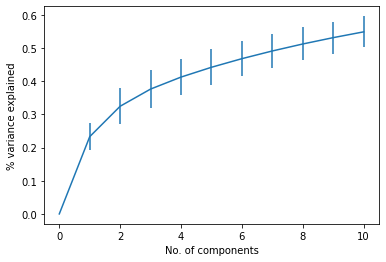

In [373]:
means, stds = make_pca_variance_plot(results, 200, save=True, experiment="lin")

In [515]:
results[200][0]["pca_results"].round(2)

,pca_var_exp,corr_with_base_feat,corr_with_target,y_var_explained,y_var_exp_norm,t-statistic
0,0.24,-0.93,-0.93,0.04,1.50,-4.68
1,0.08,-0.07,-0.07,0.00,0.01,-0.40
2,0.06,0.28,0.28,0.00,0.03,-0.71
3,0.04,-0.13,-0.13,0.01,0.23,1.84
4,0.03,0.07,0.07,0.00,0.06,0.95
5,0.03,0.03,0.03,0.00,0.13,1.38
6,0.02,-0.07,-0.07,0.01,0.49,-2.68
7,0.02,-0.01,-0.01,0.01,0.21,-1.73
8,0.02,-0.02,-0.02,0.01,0.40,2.42
9,0.02,-0.01,-0.01,0.03,1.06,3.93


In [516]:
results[200][0]["tree_transformer"].pca

TreeTransformer(estimator=RandomForestRegressor(max_features=0.33,
                                                random_state=405),
                max_components=10)

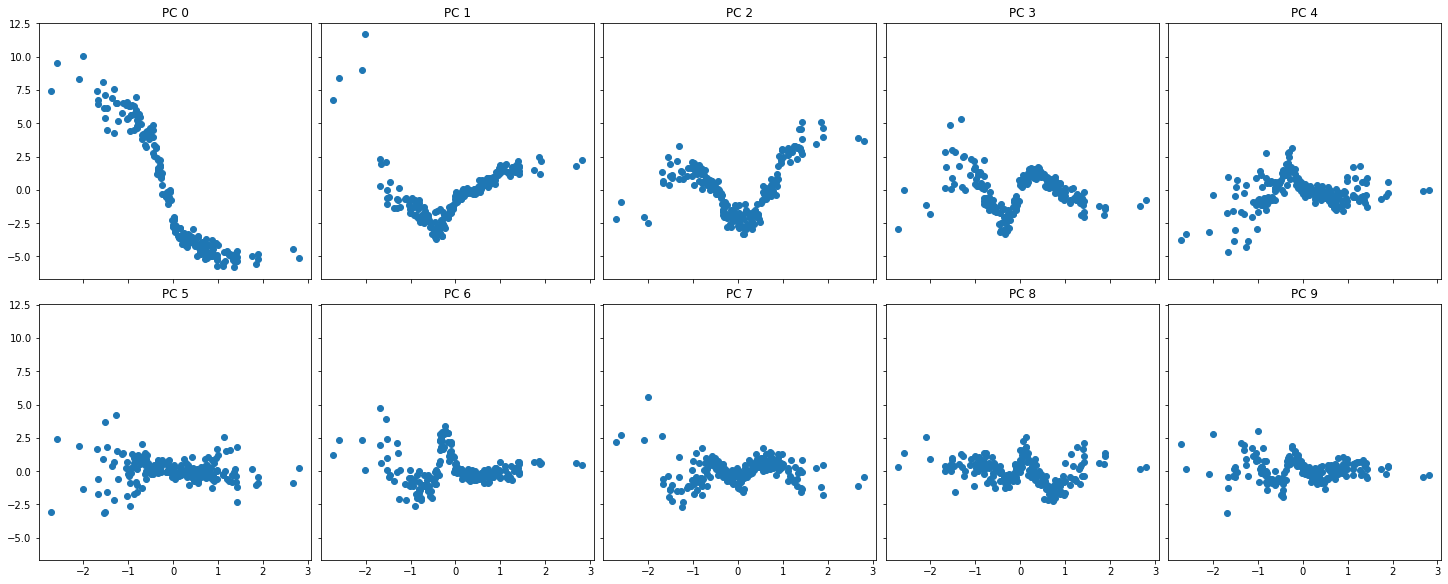

In [453]:
n = 200
X = np.random.randn(n, p)
make_plot(results[200][0]["tree_transformer"], X, c_plotted=10, save=True, experiment="lin")

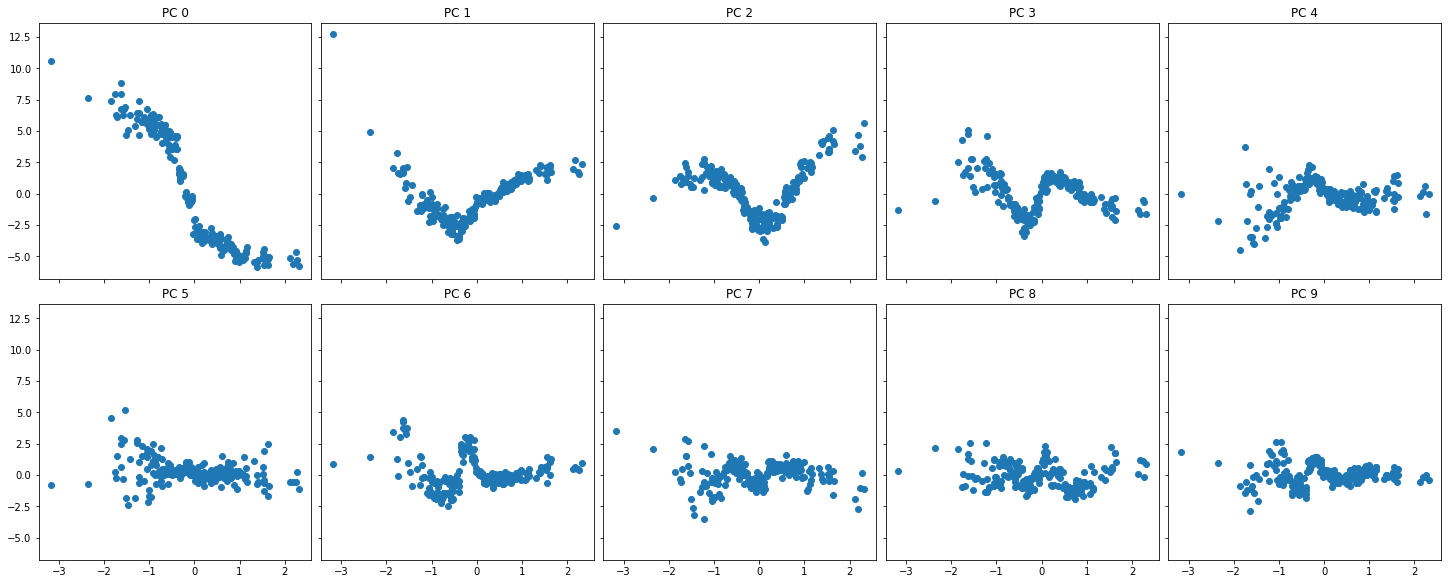

In [460]:
n = 200
X = np.random.randn(n, p)
make_plot(results[200][0]["tree_transformer"], X, c_plotted=10, save=True, experiment="lin", reference_feat=0)

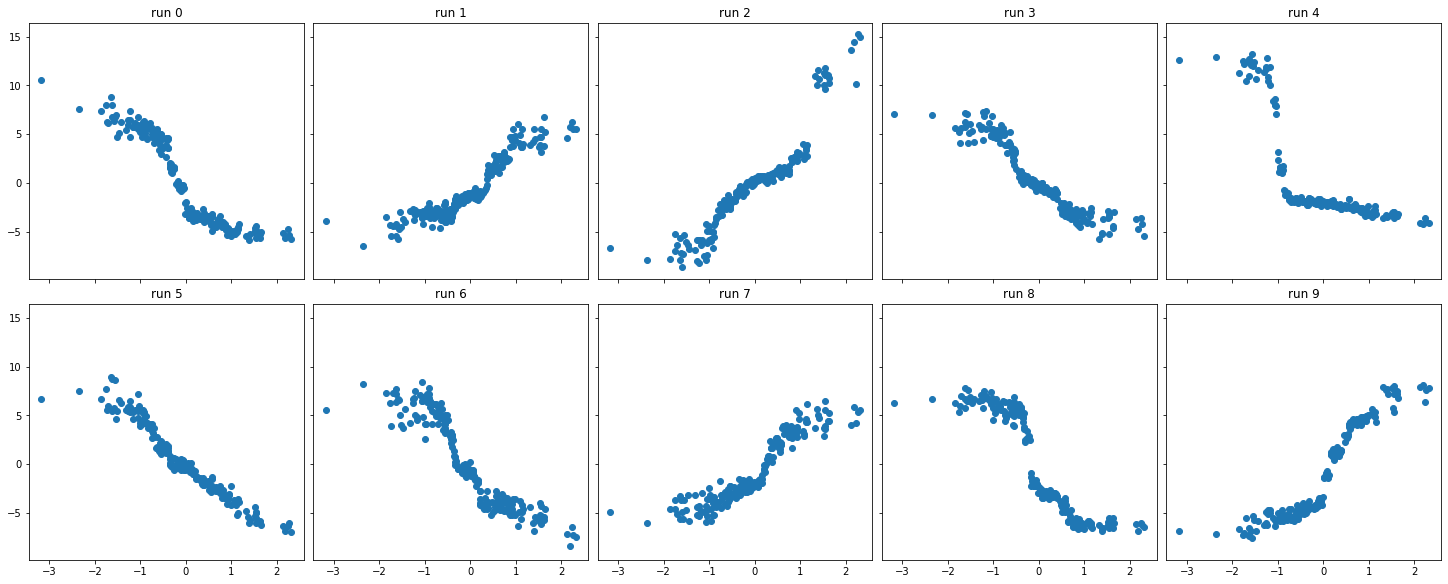

In [461]:
plot_across_runs(results, X, vary_n=False, pc_no=0, save=True, experiment_name="lin_PC0_across_runs", n=200)

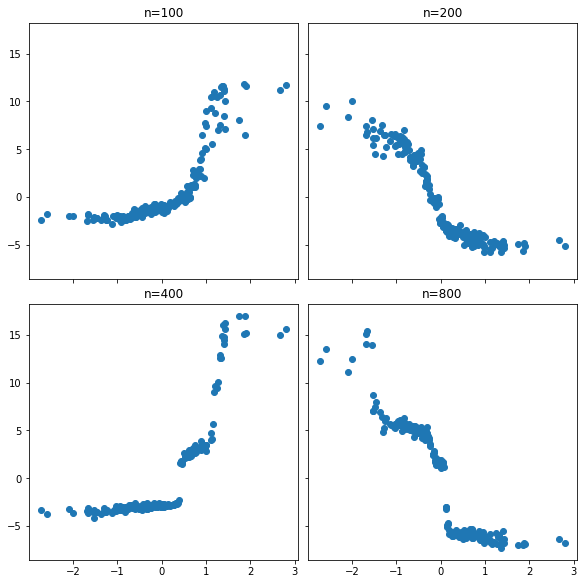

In [376]:
plot_across_runs(results, X, vary_n=True, pc_no=0, save=True, experiment_name="lin_PC0_across_n")

In [223]:
#make_2d_plot(tree_transformer, X_val, c_plotted=6, save=False, experiment="lin")

## 2. Sum of squares

In [385]:
n_grid = [100, 200, 400, 800]
p = 10
k = 0
params = {"s": 2,
          "sigma": 5,
          "beta": 1}
target_func = lambda Z : Z[:,k] ** 2
# ss_results = run_sims(sum_of_squares, n_grid, p, params, k, target_func)
output_file = "results/ss_pca_experiment.pkl"
# pkl.dump(results, open(output_file, "wb"))
# results = pkl.load(open(output_file, "rb"))

100%|██████████| 4/4 [01:11<00:00, 17.90s/it]


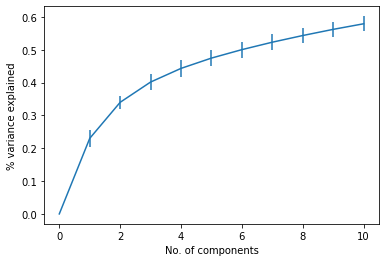

In [387]:
means, stds = make_pca_variance_plot(ss_results, 200, save=True, experiment="ss")

In [480]:
ss_results[200][1]["pca_results"][["corr_with_base_feat", "corr_with_target", "y_var_explained", "t-statistic"]].round(2)

,corr_with_base_feat,corr_with_target,y_var_explained,t-statistic
0,-0.85,0.51,0.01,0.40
1,0.45,0.75,0.04,0.71
2,-0.15,0.08,0.01,0.36
3,0.01,0.09,0.01,-0.35
4,0.11,0.10,0.00,0.22
5,0.02,0.13,0.00,-0.16
6,0.01,-0.02,0.00,0.24
7,-0.05,-0.04,0.00,0.18
8,0.12,-0.23,0.02,-0.55
9,-0.04,-0.00,0.00,-0.17


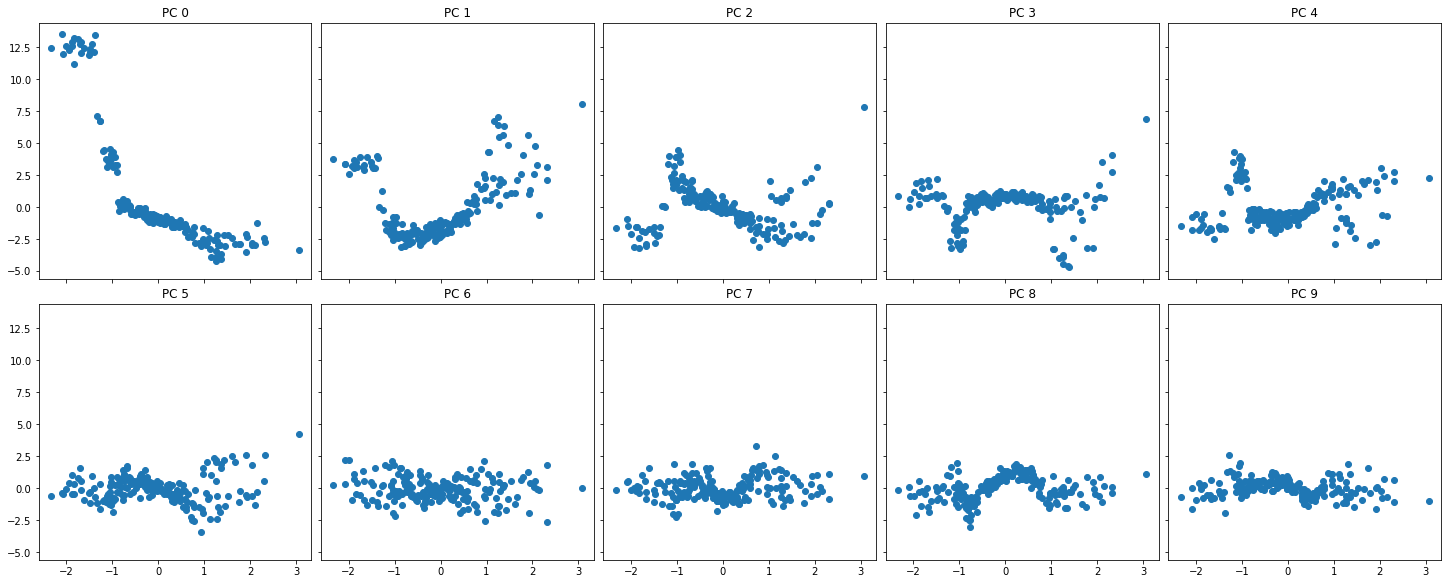

In [475]:
n = 200
X = np.random.randn(n, p)
make_plot(ss_results[n][1]["tree_transformer"], X, c_plotted=10, save=True, experiment="ss")

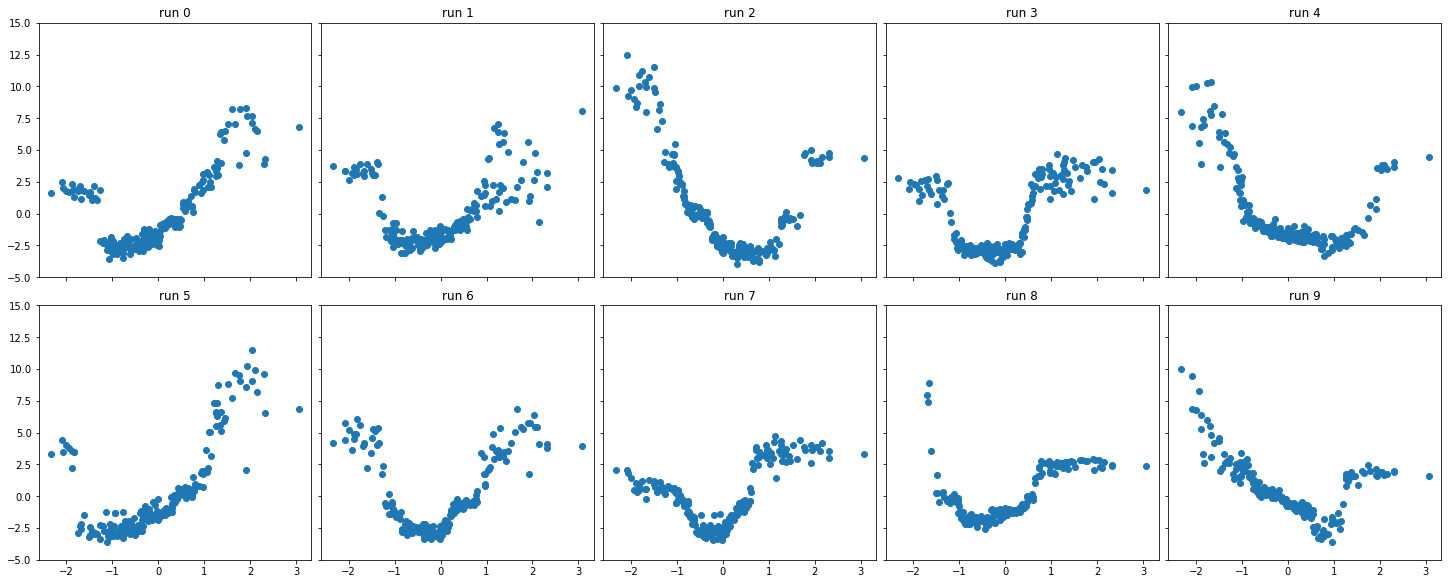

In [482]:
plot_across_runs(ss_results, X, vary_n=False, pc_no=1, save=True, experiment_name="ss_PC1_across_runs", n=200, ylim=[-5,15])

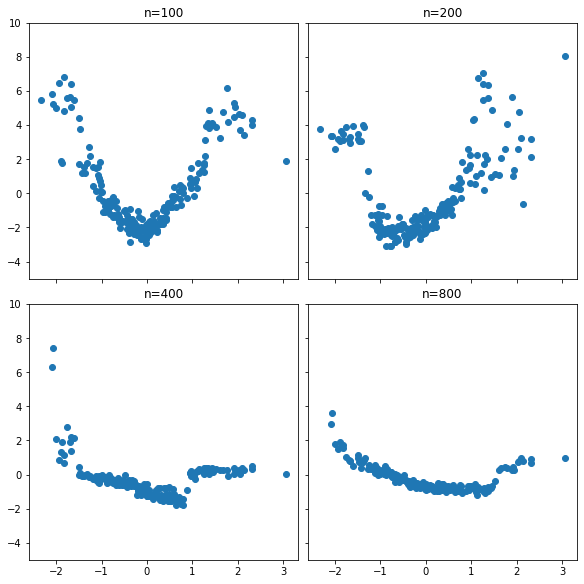

In [483]:
plot_across_runs(ss_results, X, vary_n=True, pc_no=1, save=True, experiment_name="ss_PC1_across_n", r=1, ylim=[-5,10])

## 3. LSS

In [437]:
n_grid = [100, 200, 400, 800]
p = 10
k = 0
params = {"m": 1,
          "r": 2,
          "tau": 0,
          "sigma": 1,
          "beta": 1}
target_func = lambda Z : (Z[:,k] > 0) & (Z[:,k+1] > 0)
lss_results = run_sims(lss_model, n_grid, p, params, k, target_func)
output_file = "results/lss_pca_experiment.pkl"
# pkl.dump(results, open(output_file, "wb"))
# results = pkl.load(open(output_file, "rb"))

100%|██████████| 4/4 [01:54<00:00, 28.61s/it]


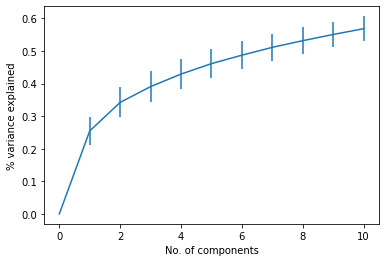

(array([0.        , 0.25466675, 0.34233232, 0.3907083 , 0.42921651,
        0.46124485, 0.4872289 , 0.51118948, 0.53172388, 0.55075654,
        0.56842303]),
 array([0.        , 0.04278107, 0.04635524, 0.04740273, 0.04582238,
        0.04504521, 0.04348052, 0.0419314 , 0.040688  , 0.03947954,
        0.03825676]))

In [438]:
make_pca_variance_plot(lss_results, 200, save=True, experiment="lss")

In [484]:
lss_results[200][0]["pca_results"][["corr_with_base_feat", "corr_with_target", "y_var_explained", "t-statistic"]].round(2)

,corr_with_base_feat,corr_with_target,y_var_explained,t-statistic
0,-0.89,-0.48,0.05,-0.97
1,0.24,-0.23,0.04,-0.82
2,-0.24,0.27,0.01,0.45
3,-0.11,-0.04,0.01,-0.33
4,0.12,0.36,0.01,0.42
5,-0.04,-0.25,0.00,-0.24
6,0.03,-0.03,0.00,0.14
7,0.08,-0.16,0.03,0.68
8,0.12,-0.06,0.02,-0.60
9,-0.06,0.08,0.00,-0.24


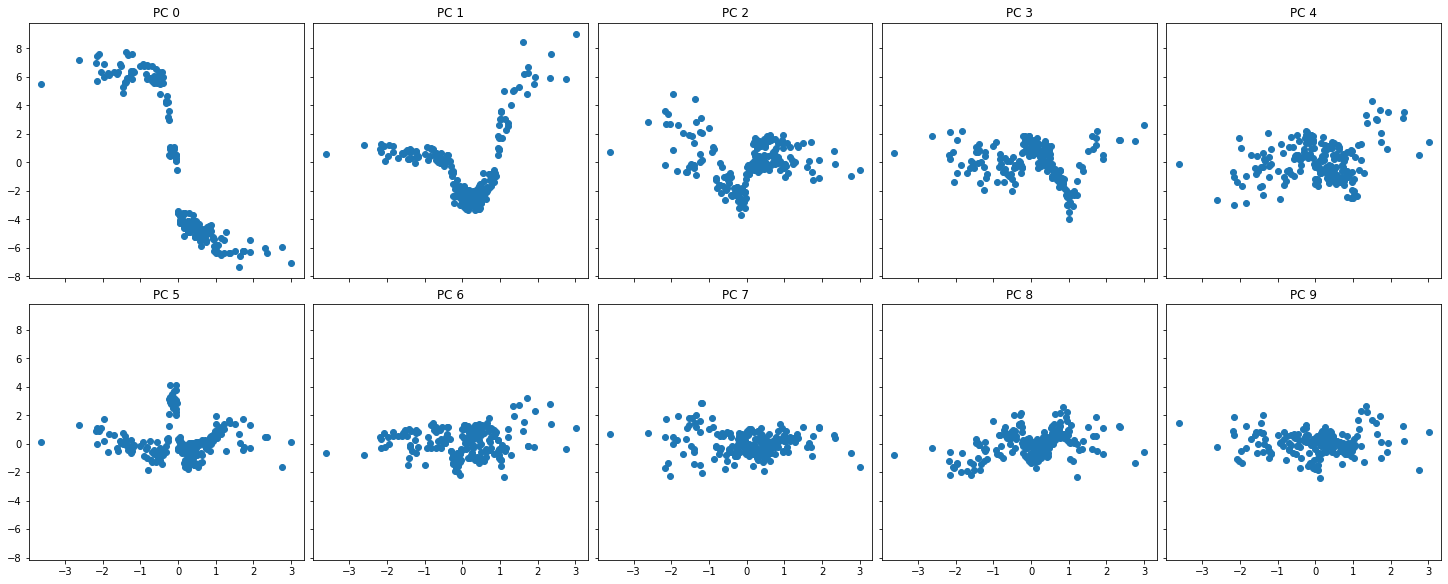

In [488]:
n = 200
X = np.random.randn(n, p)
make_plot(lss_results[n][0]["tree_transformer"], X, c_plotted=10, save=True, experiment="lss")

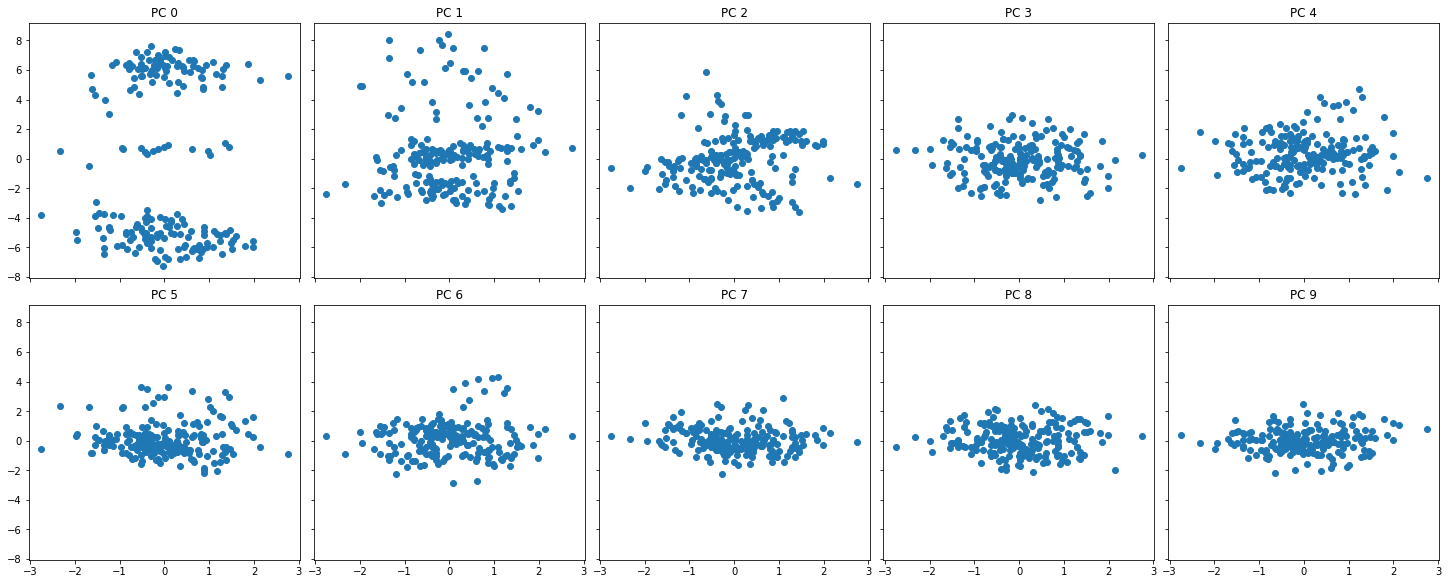

In [487]:
n = 200
X = np.random.randn(n, p)
make_plot(lss_results[n][0]["tree_transformer"], X, c_plotted=10, save=False, experiment="lss", original_feat=1)

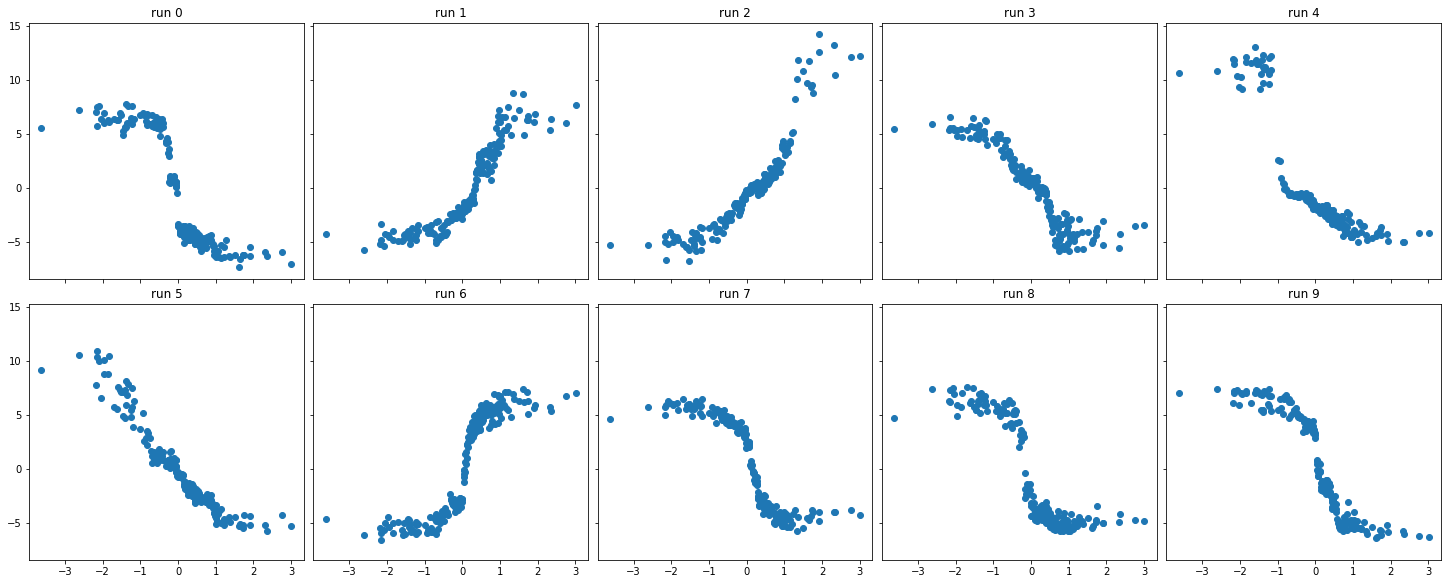

In [491]:
plot_across_runs(lss_results, X, vary_n=False, pc_no=0, save=True, experiment_name="lss_PC0_across_runs", n=200)

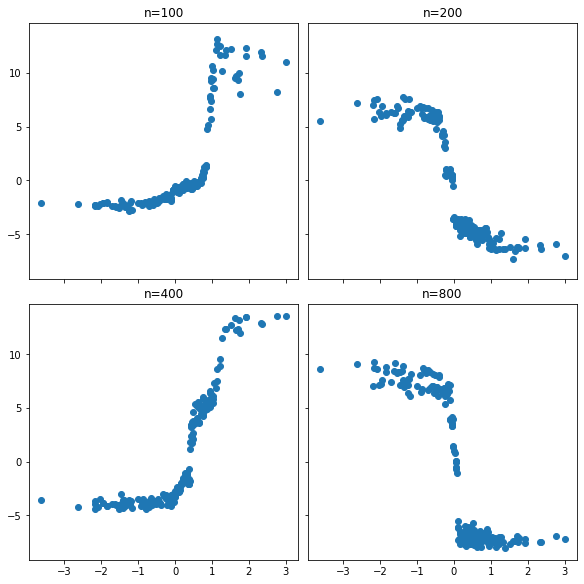

In [492]:
plot_across_runs(lss_results, X, vary_n=True, pc_no=0, save=True, experiment_name="lss_PC0_across_n", r=0)

## 4. Linear model, normalize stumps

## 4. Linear model, normalize stumps

In [3]:
n_grid = [100, 200, 400, 800]
p = 10
k = 0
params = {"s": 2,
          "sigma": 5,
          "beta": 1}
results_nn = run_sims(linear_model, n_grid, p, params, k, normalize=True)
# output_file = "results/lin_pca_experiment.pkl"
# pkl.dump(results, open(output_file, "wb"))
# results = pkl.load(open(output_file, "rb"))

100%|██████████| 4/4 [01:03<00:00, 15.92s/it]


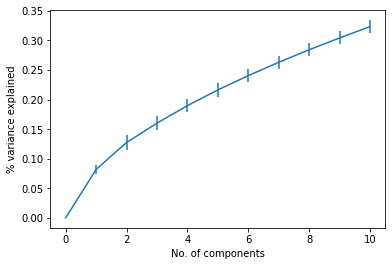

In [4]:
means, stds = make_pca_variance_plot(results_nn, 200, save=False, experiment="lin")

In [5]:
results_nn[200][0]["pca_results"].round(2)

,pca_var_exp,corr_with_base_feat,corr_with_target,y_var_explained,y_var_exp_norm,t-statistic
0,0.08,-0.94,-0.94,0.04,1.45,-4.60
1,0.04,0.09,0.09,0.00,0.00,-0.23
2,0.03,0.08,0.08,0.01,0.44,-2.54
3,0.03,-0.20,-0.20,0.00,0.00,-0.11
4,0.03,0.09,0.09,0.00,0.01,0.43
5,0.02,0.01,0.01,0.00,0.00,0.22
6,0.02,0.01,0.01,0.04,1.48,4.64
7,0.02,0.06,0.06,0.00,0.01,0.43
8,0.02,-0.07,-0.07,0.00,0.03,-0.70
9,0.02,0.09,0.09,0.00,0.08,1.06


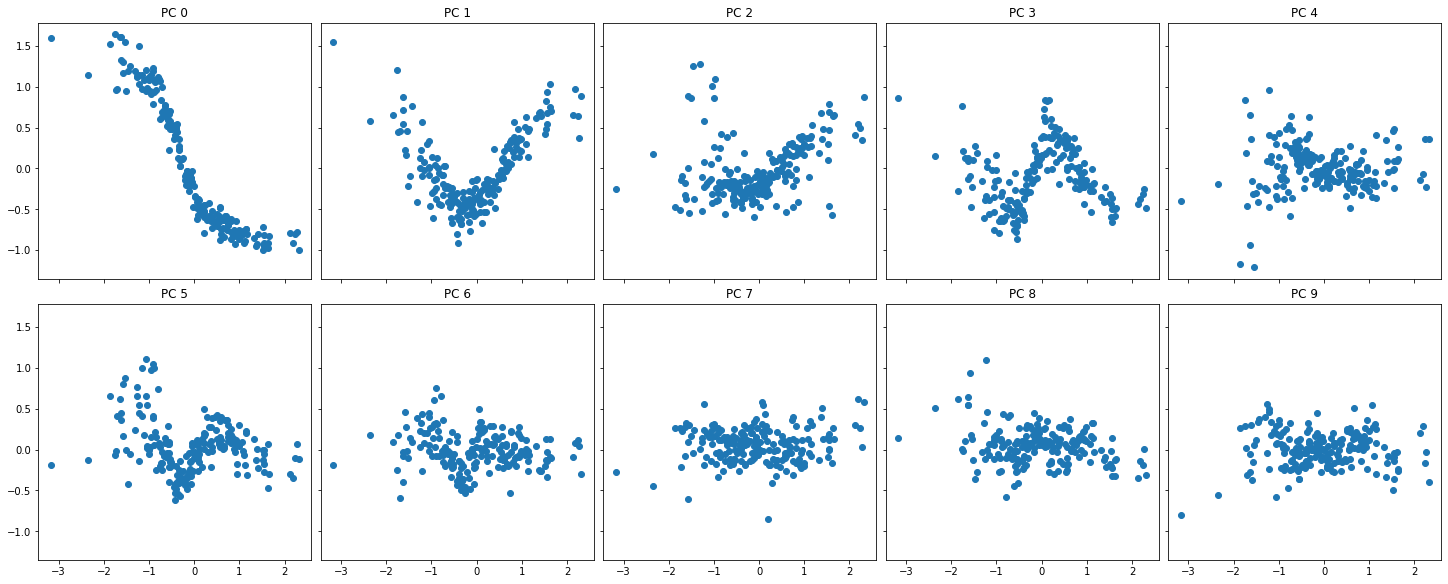

In [10]:
n = 200
X = np.random.randn(n, p)
make_plot(results_nn[200][0]["tree_transformer"], X, c_plotted=10, save=False, experiment="lin", original_feat=0)

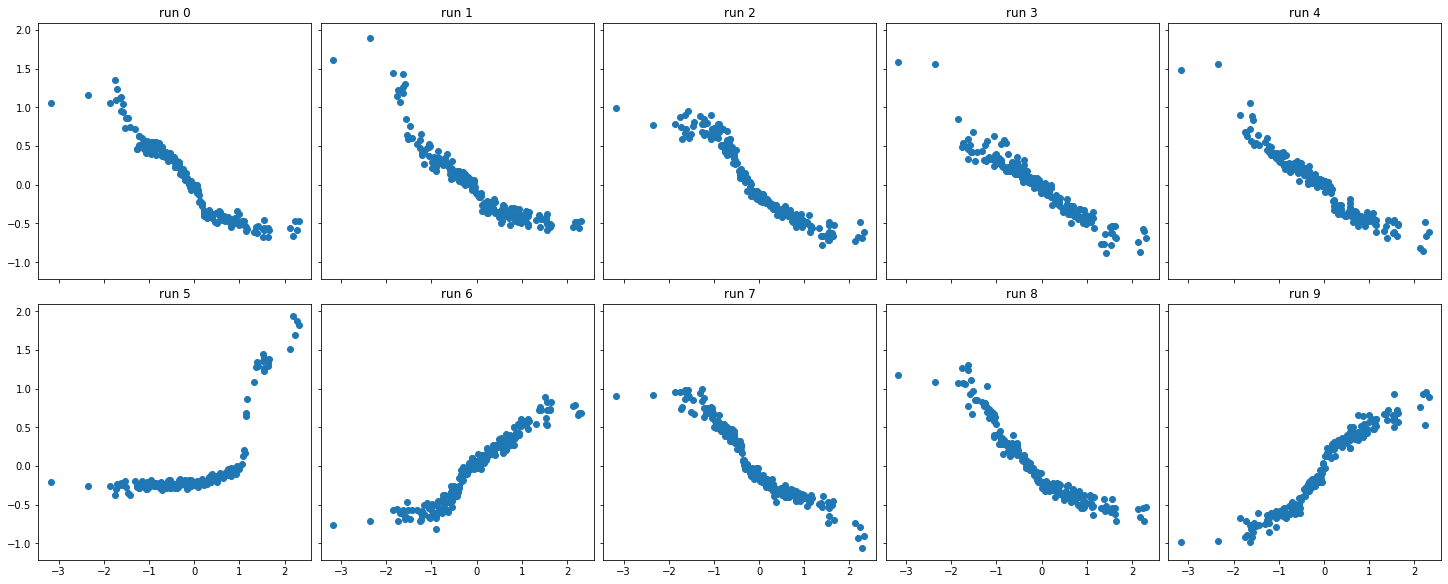

In [14]:
plot_across_runs(results_nn, X, vary_n=False, pc_no=0, save=False, experiment_name="lin_PC0_across_runs", n=800)

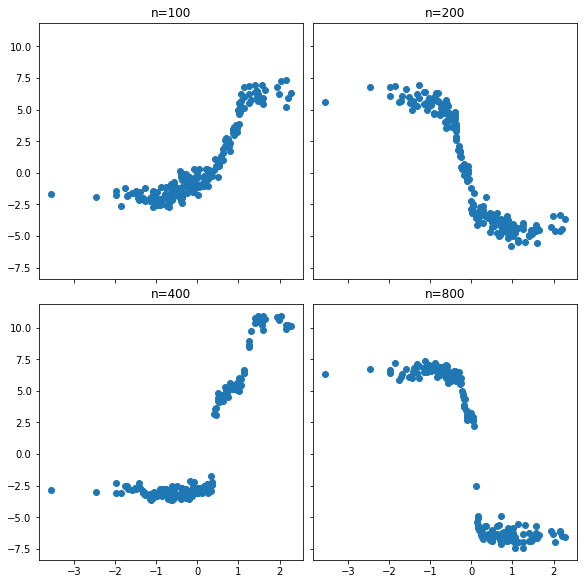

In [511]:
plot_across_runs(results_nn, X, vary_n=True, pc_no=0, save=False, experiment_name="lin_PC0_across_n")

## 5. SS with normalizations

In [31]:
n_grid = [100, 200, 400, 800]
p = 10
k = 0
params = {"s": 2,
          "sigma": 5,
          "beta": 1}
target_func = lambda Z : Z[:,k] ** 2
results_ss_nn = run_sims(sum_of_squares, n_grid, p, params, k, normalize=True, target_func=target_func)

# output_file = "results/lin_pca_experiment.pkl"
# pkl.dump(results, open(output_file, "wb"))
# results = pkl.load(open(output_file, "rb"))

100%|██████████| 4/4 [01:18<00:00, 19.54s/it]


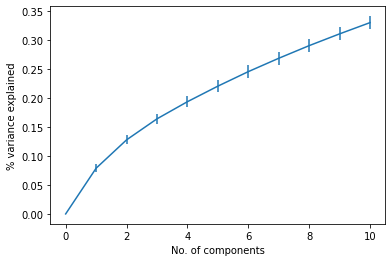

(array([0.        , 0.07877079, 0.12764764, 0.16390416, 0.19345844,
        0.22026426, 0.24529705, 0.26831278, 0.29010741, 0.31041564,
        0.32980988]),
 array([0.        , 0.00651224, 0.00763028, 0.00876349, 0.0094931 ,
        0.01002284, 0.01062298, 0.01093717, 0.01118328, 0.01112738,
        0.01097875]))

In [32]:
make_pca_variance_plot(results_ss_nn, 200, save=False, experiment="lin")

In [35]:
results_ss_nn[200][3]["pca_results"].round(2)

,pca_var_exp,corr_with_base_feat,corr_with_target,y_var_explained,y_var_exp_norm,t-statistic
0,0.09,-0.93,0.31,0.00,0.02,0.10
1,0.04,0.06,0.53,0.00,0.01,0.07
2,0.04,-0.06,0.01,0.01,0.22,0.33
3,0.03,0.11,0.08,0.05,1.43,0.85
4,0.03,0.02,0.11,0.00,0.02,0.11
5,0.02,0.02,-0.00,0.01,0.28,-0.38
6,0.02,0.02,0.12,0.00,0.07,0.19
7,0.02,0.08,-0.06,0.02,0.56,0.53
8,0.02,-0.01,0.01,0.00,0.00,-0.01
9,0.02,0.06,-0.04,0.01,0.25,0.35


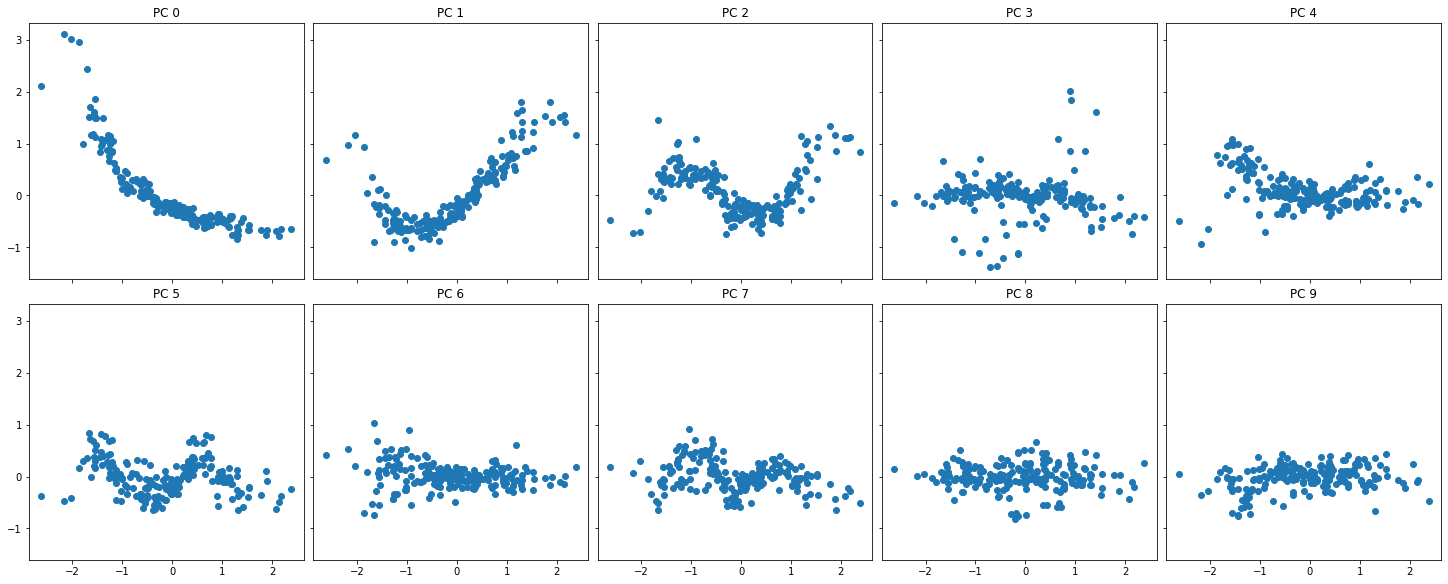

In [41]:
n = 200
X = np.random.randn(n, p)
make_plot(results_ss_nn[200][5]["tree_transformer"], X, c_plotted=10, save=False, experiment="ss", original_feat=0)

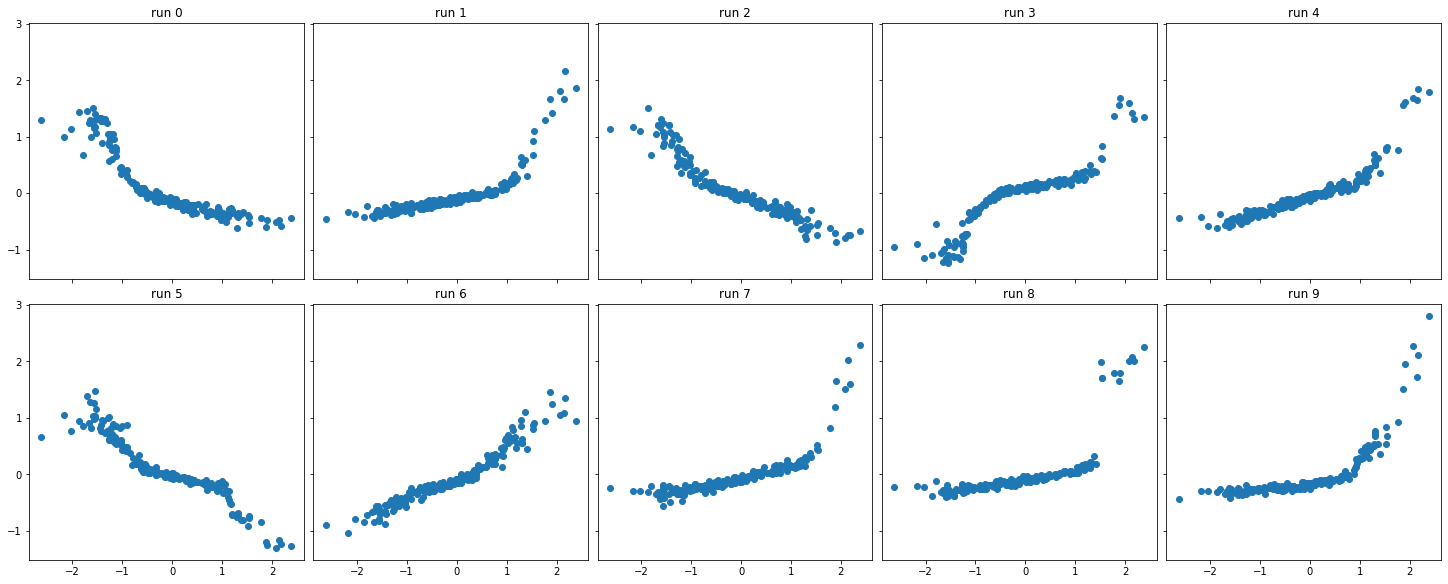

In [47]:
plot_across_runs(results_ss_nn, X, vary_n=False, pc_no=0, save=False, experiment_name="ss_PC1_across_runs", n=800)

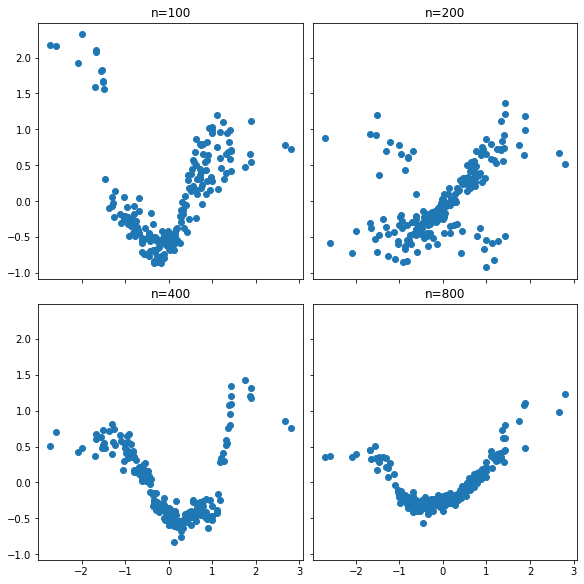

In [30]:
plot_across_runs(results_ss_nn, X, vary_n=True, pc_no=1, save=False, experiment_name="ss_PC1_across_n")